In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import cupy as cp
from cupy.linalg import eigh as cp_eigh

# ============================================================================
# Paramètres fixes
# ============================================================================
n_basis     = 10
sigma_coeff = 1.0
sigma_noise = 0.05
alpha       = 1.0
B           = 299
M           = 199
a_grid      = np.linspace(0, 0.2, 100)

n_vals = [100, 500]
p_vals = [100, 500, 1000]

C_CONST = (2.0 / 9.0) * np.exp(3)

def get_t(p):
    return (np.arange(1, p + 1) - 0.5) / p

def gen_fourier(a, n, t, seed):
    """Génère n courbes Fourier avec moyenne a."""
    np.random.seed(seed)
    p     = len(t)
    basis = []
    for k in range(1, n_basis + 1):
        basis.append(0.25 * np.sin(np.pi * k * t))
        basis.append(0.25 * np.cos(np.pi * k * t))
    basis  = np.array(basis).T
    curves = np.zeros((n, p))
    for i in range(n):
        coeff     = np.random.normal(0, sigma_coeff, size=2 * n_basis)
        noise     = np.random.normal(0, sigma_noise, size=p)
        curves[i] = a + basis @ coeff + noise
    return curves

def theoretical_bound(eigvals, alpha, delta=0.05):
    c         = np.log(C_CONST / delta)
    ratios    = eigvals / (eigvals + alpha)
    Theta1    = np.sum(ratios)
    Theta2    = np.sqrt(np.sum(ratios**2))
    Theta_inf = np.max(ratios)
    return Theta1 + 2 * Theta2 * (np.sqrt(c) + (Theta_inf / Theta2) * c)

def get_ref_eigvals(n, p):
    """
    Valeurs propres de référence sous H0 (a=0, a2=0) pour le calcul de la borne.
    On génère les deux échantillons sous H0 et on calcule la covariance de la différence.
    """
    t    = get_t(p)
    X1   = gen_fourier(0.0, n, t, seed=11111)
    X2   = gen_fourier(0.0, n, t, seed=22222)
    D    = (X1 - X2) / np.sqrt(2)          # différence normalisée, même loi que X1
    D_cp = cp.asarray(D)
    Gamma = (D_cp.T @ D_cp) / n
    eigvals_cp, _ = cp_eigh(Gamma)
    return cp.asnumpy(eigvals_cp)[::-1]     # ordre décroissant

def run_two_sample_gpu(args):
    """
    Two-sample test via réduction one-sample sur D_i = (X1_i - X2_i) / sqrt(2).
    Sous H0 : E[D_i] = 0.
    Sous H1 : E[D_i] = a / sqrt(2) * 1  (shift de a sur le 2e échantillon).
    """
    n, p, a_grid, alpha, B, M = args
    t          = get_t(p)
    eigvals_ref = get_ref_eigvals(n, p)
    bound       = theoretical_bound(eigvals_ref, alpha, delta=0.05)

    pw_perm  = np.zeros(len(a_grid))
    pw_bound = np.zeros(len(a_grid))

    for i, a in tqdm(enumerate(a_grid), total=len(a_grid),
                     desc=f"  n={n}, p={p}", leave=True):
        rej_perm  = 0
        rej_bound = 0

        for rep in range(M):
            # Echantillon 1 : moyenne 0 ; Echantillon 2 : moyenne a
            X1 = gen_fourier(0.0, n, t, seed=rep + i * 10000)
            X2 = gen_fourier(a,   n, t, seed=rep + i * 10000 + 500000)
            D  = (X1 - X2) / np.sqrt(2)   # one-sample réduit, moyenne -a/sqrt(2) sous H1

            Z     = cp.asarray(D)
            Gamma = (Z.T @ Z) / n
            eigvals_cp, eigvecs_cp = cp_eigh(Gamma)
            idx     = cp.argsort(eigvals_cp)[::-1]
            eigvals = eigvals_cp[idx]
            eigvecs = eigvecs_cp[:, idx]

            U     = Z @ eigvecs
            S     = U.sum(axis=0)
            denom = n * (eigvals + alpha)
            T_obs = float(cp.sum(S**2 / denom))

            if T_obs >= bound:
                rej_bound += 1

            signs  = cp.random.choice(cp.array([-1.0, 1.0]), size=(B, n))
            S_perm = signs @ U
            T_perm = cp.sum(S_perm**2 / denom, axis=1)
            p_val  = float((1 + cp.sum(T_perm >= T_obs)) / (B + 1))
            if p_val < 0.05:
                rej_perm += 1

        pw_perm[i]  = rej_perm  / M
        pw_bound[i] = rej_bound / M

    return (n, p), pw_perm, pw_bound

def plot_single_n(results_perm, results_bound, n, p_vals, a_grid, save_dir):
    fig, axes = plt.subplots(1, len(p_vals), figsize=(15, 5))
    for j, p in enumerate(p_vals):
        ax = axes[j]
        ax.plot(a_grid, results_perm[(n, p)],
                'r-o', linewidth=2, markersize=2, label='Sign-flip permutation')
        ax.plot(a_grid, results_bound[(n, p)],
                'b-s', linewidth=2, markersize=2, label='Theoretical bound')
        ax.axhline(y=0.05, color='k', linestyle='--', linewidth=1, label='Nominal 5%')
        ax.set_title(f'n={n}, p={p}')
        ax.set_xlabel('a')
        ax.set_ylabel('Power')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, linestyle=':')
        if j == 0:
            ax.legend(fontsize=8)
    plt.suptitle(
        f'Two-sample test — Fourier design — n={n}\n'
        'Red = sign-flip permutation  |  Blue = theoretical bound',
        fontsize=13
    )
    plt.tight_layout()
    fname = f'power_two_sample_fourier_n{n}'
    plt.savefig(f'{save_dir}/{fname}.pdf')
    plt.savefig(f'{save_dir}/{fname}.png', dpi=150)
    plt.show()
    print(f"  -> {fname}.png sauvegardé")

def plot_all(results_perm, results_bound, n_vals, p_vals, a_grid, save_dir):
    fig, axes = plt.subplots(len(n_vals), len(p_vals), figsize=(15, 10))
    for i, n in enumerate(n_vals):
        for j, p in enumerate(p_vals):
            ax = axes[i, j]
            ax.plot(a_grid, results_perm[(n, p)],
                    'r-o', linewidth=2, markersize=2, label='Sign-flip permutation')
            ax.plot(a_grid, results_bound[(n, p)],
                    'b-s', linewidth=2, markersize=2, label='Theoretical bound')
            ax.axhline(y=0.05, color='k', linestyle='--', linewidth=1, label='Nominal 5%')
            ax.set_title(f'n={n}, p={p}')
            ax.set_xlabel('a')
            ax.set_ylabel('Power')
            ax.set_ylim([-0.05, 1.05])
            ax.grid(True, linestyle=':')
            if i == 0 and j == 0:
                ax.legend(fontsize=8)
    plt.suptitle(
        'Two-sample test — Fourier design\n'
        'Red = sign-flip permutation  |  Blue = theoretical bound',
        fontsize=13
    )
    plt.tight_layout()
    fname = 'power_two_sample_fourier_all'
    plt.savefig(f'{save_dir}/{fname}.pdf')
    plt.savefig(f'{save_dir}/{fname}.png', dpi=150)
    plt.show()
    print(f"  -> {fname}.png sauvegardé")

  Two-sample Fourier — n=100


  n=100, p=1000: 100%|██████████| 100/100 [23:59<00:00, 14.39s/it]


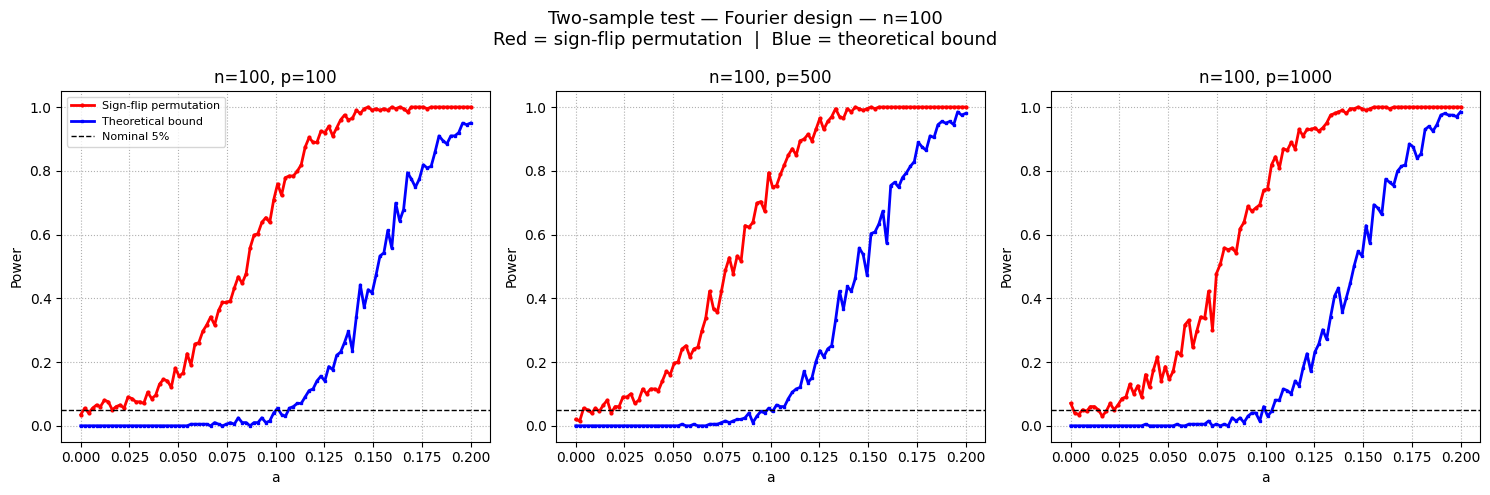

  -> power_two_sample_fourier_n100.png sauvegardé


In [ ]:
save_dir = '/content/drive/MyDrive/Graphics3'
n        = 100

print(f"{'='*60}\n  Two-sample Fourier — n={n}\n{'='*60}")

tasks = [(n, p, a_grid, alpha, B, M) for p in p_vals]

results_perm  = {}
results_bound = {}

for (n_res, p), pw_perm, pw_bound in map(run_two_sample_gpu, tasks):
    results_perm[(n_res, p)]  = pw_perm
    results_bound[(n_res, p)] = pw_bound

plot_single_n(results_perm, results_bound, n, p_vals, a_grid, save_dir)

  Two-sample Fourier — n=500


  n=500, p=1000: 100%|██████████| 100/100 [45:10<00:00, 27.10s/it]


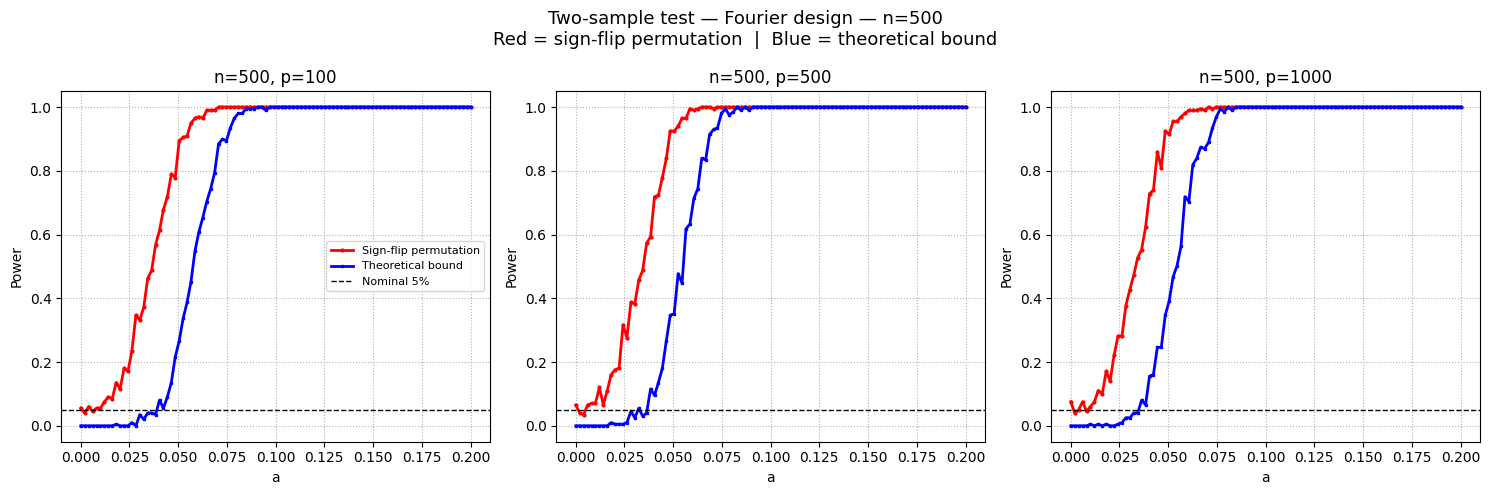

  -> power_two_sample_fourier_n500.png sauvegardé


In [ ]:
n = 500

print(f"{'='*60}\n  Two-sample Fourier — n={n}\n{'='*60}")

tasks = [(n, p, a_grid, alpha, B, M) for p in p_vals]

for (n_res, p), pw_perm, pw_bound in map(run_two_sample_gpu, tasks):
    results_perm[(n_res, p)]  = pw_perm
    results_bound[(n_res, p)] = pw_bound

plot_single_n(results_perm, results_bound, n, p_vals, a_grid, save_dir)

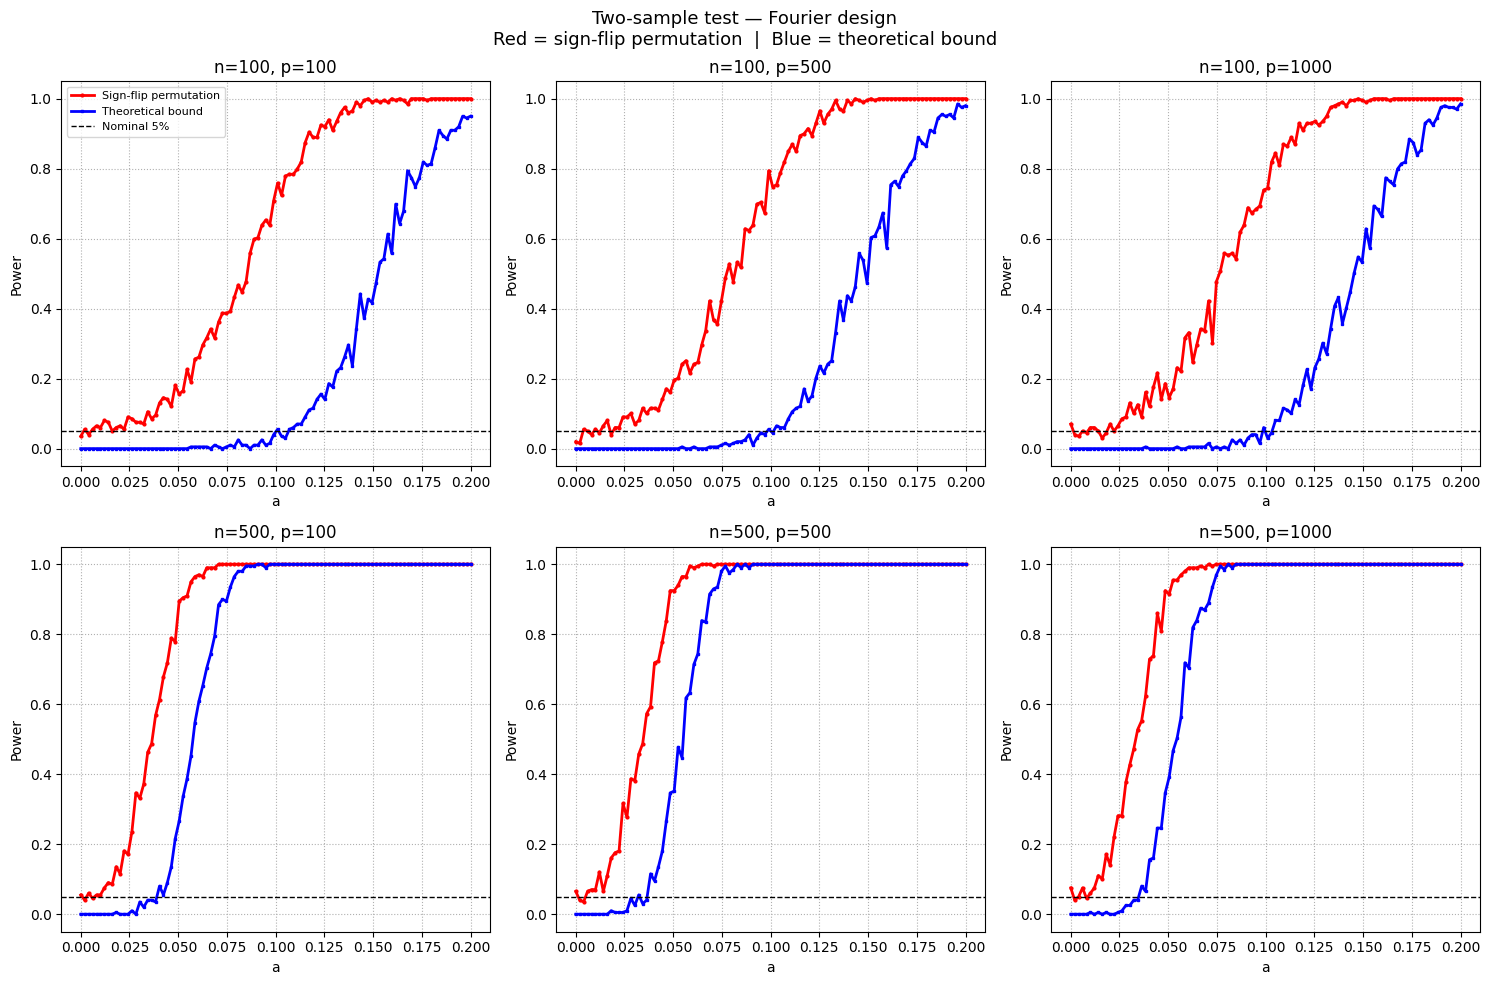

  -> power_two_sample_fourier_all.png sauvegardé


In [ ]:
plot_all(results_perm, results_bound, n_vals, p_vals, a_grid, save_dir)